# Libraries and parameters

In [14]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from loguru import logger
from datasets.data import read_csv_files, extract_features
from datasets.processing import (
    stratified_kfold_split,
    make_columns_categorical,
    compute_time_ratios,
)
from bayesian.learn import learn_bayesian_network, display_and_save_gum_bn
from bayesian.modifiers import (
    add_public_to_target_arcs,
    add_sensible_to_target_arcs,
    simplification_1,
    extract_markov_blanket,
    filter_relevant_features,
)
from bayesian.inference import (
    build_inference_engine,
    compute_posteriors_given_sensible_features_combinations,
)
from metrics.evaluate import evaluate_bn_performance, evaluate_bn_performance_aggregate
from metrics.fairness import (
    compute_group_fairness_metrics,
    save_metrics_dict,
    compute_individual_fairness,
    analyze_individual_fairness_metrics,
    compute_individual_fairness_MRF,
)
from visualization.bayesnet import visualize_bn
from visualization.metrics import plot_boxplot_timeratios, plot_brier_vs_robustness
import sys

# KEEP LOGURU OUTPUT CLEAN but preserve level colors
logger.remove()
logger.add(sys.stdout, colorize=True, format="<level>{message}</level>")


# Check that the notebook is running from the correct directory,
# this may require adjustment depending on your setup
data_path = Path("./data/")
save_path = Path("./data/notebook_results/crossval/")

data_path.mkdir(parents=True, exist_ok=True)
save_path.mkdir(parents=True, exist_ok=True)

learning_method = "tabu"
force_arcs: bool = (
    True  # Use this flag to force sensible/public to be children of the target
)
drop_duplicates: bool = False
random_state = 42
n_splits = 10  # Number of folds for cross-validation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load datasets

In [15]:
_, dfs = read_csv_files((data_path / "preprocessed_data").as_posix())
logger.info(f"Datasets loaded from {data_path / 'preprocessed_data'}.")

Datasets loaded from data/preprocessed_data.


# Preprocess datasets

In [16]:
for key in dfs.keys():
    dfs[key] = make_columns_categorical(
        dfs[key], threshold=10, n_bins=5, encode="ordinal", strategy="uniform"
    )
logger.success("Datasets loaded and preprocessed successfully.")

Datasets loaded and preprocessed successfully.


# Main pipeline

Foreach split:
1. Split datasets into training and test sets
2. Learn Bayesian Network structure and parameters
3. Evaluate model performance
4. Compute fairness and robustness metrics
5. Aggregate and visualize results

Processing fold 1/10 for dataset law_bar_pass_prediction.
Training set size: 18464, Validation set size: 2048
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


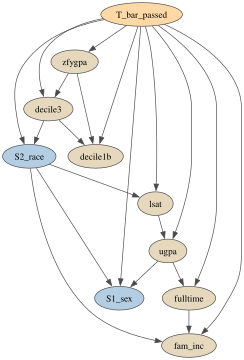

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold1_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


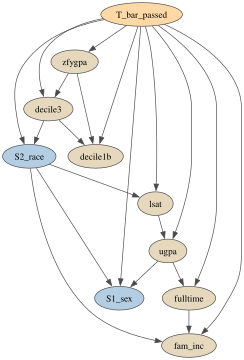

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold1_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2048/2048 [00:19<00:00, 104.47it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold1_tabu_results.csv
Processing fold 2/10 for dataset law_bar_pass_prediction.
Training set size: 18465, Validation set size: 2047
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


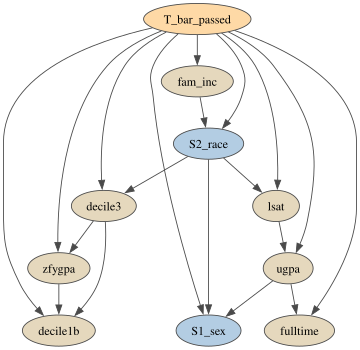

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold2_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


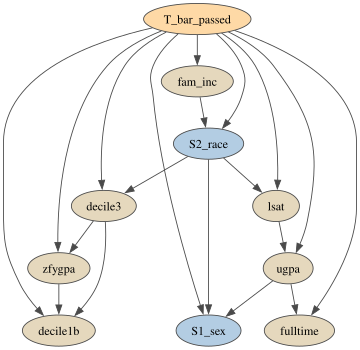

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold2_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2047/2047 [00:17<00:00, 115.25it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold2_tabu_results.csv
Processing fold 3/10 for dataset law_bar_pass_prediction.
Training set size: 18463, Validation set size: 2049
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


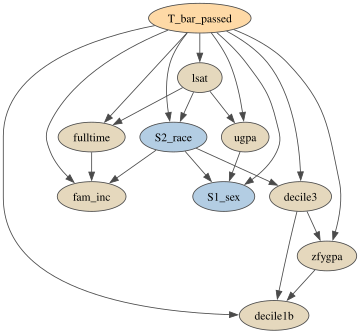

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold3_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


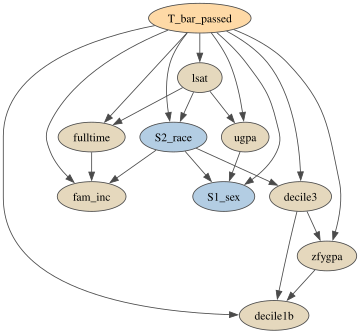

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold3_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2049/2049 [00:19<00:00, 105.27it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold3_tabu_results.csv
Processing fold 4/10 for dataset law_bar_pass_prediction.
Training set size: 18463, Validation set size: 2049
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


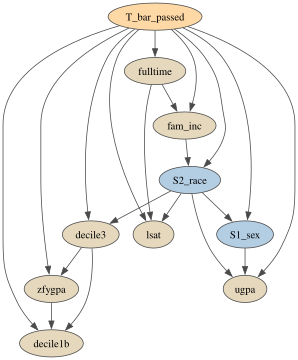

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold4_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


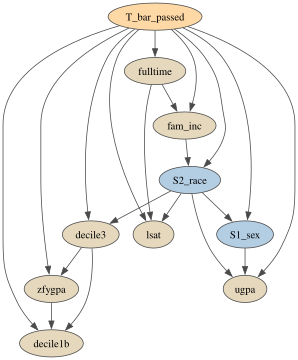

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold4_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2049/2049 [00:19<00:00, 105.55it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold4_tabu_results.csv
Processing fold 5/10 for dataset law_bar_pass_prediction.
Training set size: 18463, Validation set size: 2049
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


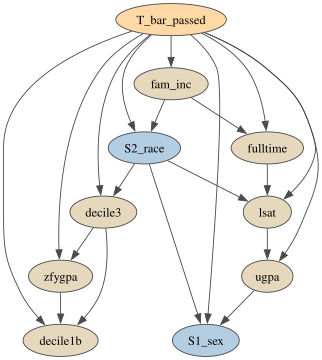

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold5_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


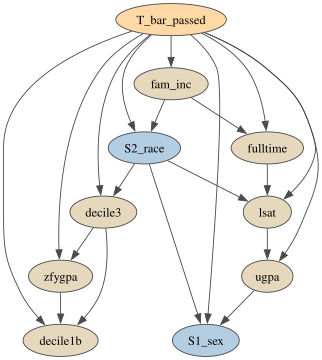

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold5_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2049/2049 [00:19<00:00, 104.81it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold5_tabu_results.csv
Processing fold 6/10 for dataset law_bar_pass_prediction.
Training set size: 18463, Validation set size: 2049
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


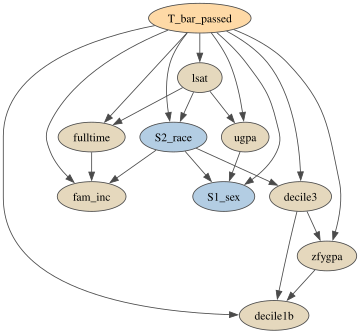

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold6_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


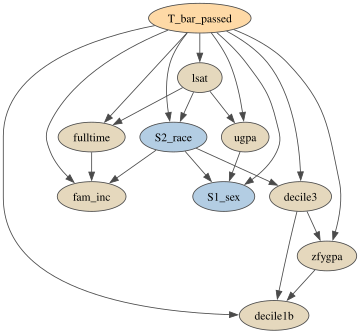

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold6_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2049/2049 [00:19<00:00, 104.66it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold6_tabu_results.csv
Processing fold 7/10 for dataset law_bar_pass_prediction.
Training set size: 18461, Validation set size: 2051
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


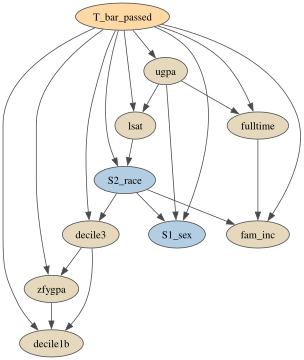

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold7_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


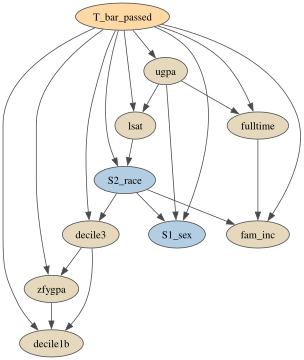

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold7_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2051/2051 [00:19<00:00, 106.85it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold7_tabu_results.csv
Processing fold 8/10 for dataset law_bar_pass_prediction.
Training set size: 18464, Validation set size: 2048
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


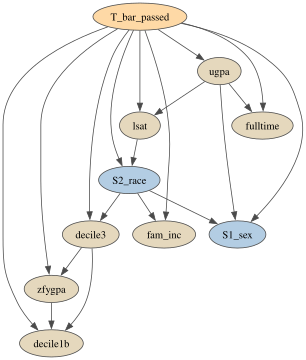

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold8_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


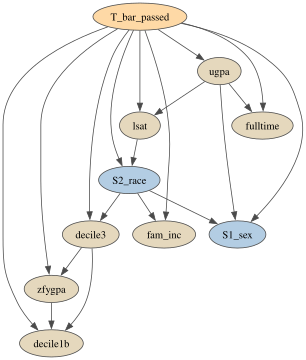

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold8_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2048/2048 [00:17<00:00, 117.54it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold8_tabu_results.csv
Processing fold 9/10 for dataset law_bar_pass_prediction.
Training set size: 18466, Validation set size: 2046
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


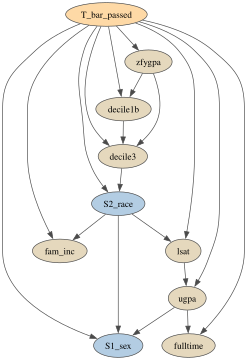

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold9_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


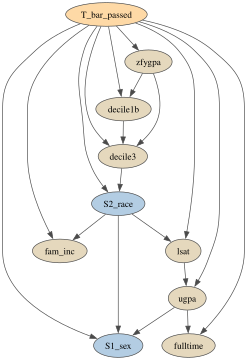

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold9_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2046/2046 [00:17<00:00, 117.58it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold9_tabu_results.csv
Processing fold 10/10 for dataset law_bar_pass_prediction.
Training set size: 18461, Validation set size: 2051
Added 2 mandatory arcs between sensible features and target
Added 7 mandatory arcs between public features and target
Learning parameters after adding sensible features: {'must_have_arcs': [('T_bar_passed', 'S1_sex'), ('T_bar_passed', 'S2_race'), ('T_bar_passed', 'decile1b'), ('T_bar_passed', 'decile3'), ('T_bar_passed', 'lsat'), ('T_bar_passed', 'ugpa'), ('T_bar_passed', 'zfygpa'), ('T_bar_passed', 'fulltime'), ('T_bar_passed', 'fam_inc')]}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...


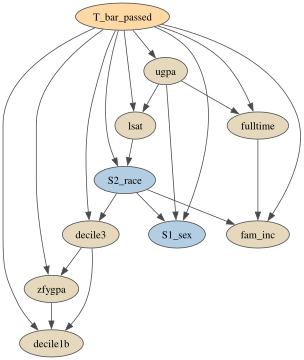

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold10_tabu.pdf
Checking for independent nodes in law_bar_pass_prediction...


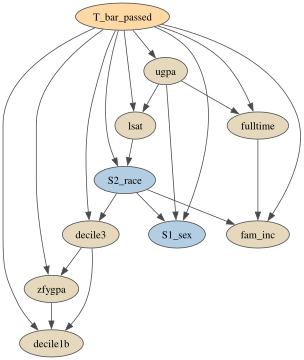

Bayesian network image saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold10_tabu.pdf
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2051/2051 [00:19<00:00, 107.32it/s]


Saved dataset with results to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_fold10_tabu_results.csv
Classification Report average cross validation: 
              precision    recall  f1-score   support

       False       0.45      0.17      0.25      1040
        True       0.96      0.99      0.97     19447

    accuracy                           0.95     20487
   macro avg       0.71      0.58      0.61     20487
weighted avg       0.93      0.95      0.94     20487

Computing individual fairness for law_bar_pass_prediction across all folds...
Analyzing individual fairness for fold 1
--------------------------------------------------------------------------
Getting Markov blanket for T_bar_passed...
Sensitive features considered for individual fairness in fold 1: ['S1_sex', 'S2_race']
Public features considered for individual fairness in fold 1: ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'fulltime', 'fam_inc']
Sensitive feature states conside

Processing rows: 100%|██████████| 2048/2048 [01:07<00:00, 30.37it/s]

Done with law_bar_pass_prediction. Processed 6144 combinations.
Analyzing individual fairness for fold 2
--------------------------------------------------------------------------
Getting Markov blanket for T_bar_passed...
Sensitive features considered for individual fairness in fold 2: ['S1_sex', 'S2_race']
Public features considered for individual fairness in fold 2: ['decile1b', 'decile3', 'lsat', 'ugpa', 'zfygpa', 'fulltime', 'fam_inc']
Sensitive feature states considered for individual fairness in fold 2: {'S1_sex': [np.str_('2'), np.str_('1')], 'S2_race': [np.str_('Other'), np.str_('White')]}
Computing individual fairness for law_bar_pass_prediction...


...

Analyzing individual fairness MRF for fold 9
--------------------------------------------------------------------------
Getting Markov blanket for T_bar_passed...
Features in MRF: {'decile1b', 'fam_inc', 'lsat', 'zfygpa', 'decile3', 'ugpa', 'S1_sex', 'S2_race', 'fulltime'}, Public features: {'decile1b', 'fam_inc', 'lsat', 'zfygpa', 'decile3', 'ugpa', 'fulltime'}, Sensible features: {'S2_race', 'S1_sex'}



MRF Inference: 100%|██████████| 2046/2046 [00:42<00:00, 48.50it/s]

Analyzing individual fairness MRF for fold 10
--------------------------------------------------------------------------
Getting Markov blanket for T_bar_passed...
Features in MRF: {'decile1b', 'fam_inc', 'lsat', 'zfygpa', 'decile3', 'ugpa', 'S1_sex', 'S2_race', 'fulltime'}, Public features: {'decile1b', 'fam_inc', 'lsat', 'zfygpa', 'decile3', 'ugpa', 'fulltime'}, Sensible features: {'S2_race', 'S1_sex'}



MRF Inference: 100%|██████████| 2051/2051 [00:46<00:00, 43.81it/s]
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/visualization/metrics.py:583: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  brier_scores = data.groupby(quantiles)["Brier_Score"].mean()
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/visualization/metrics.py:585: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  accuracy_scores = data.groupby(quantiles).apply(
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/visualization/metrics.py:583: FutureWarning: The default of observed=False is deprecated and will be changed to 

Plot saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_individual_fairness_man_Brier_brier_vs_robustness
Plot saved to data/notebook_results/crossval/law_bar_pass_prediction/law_bar_pass_prediction_individual_fairness_man_Accuracy_brier_vs_robustness
Saving boxplot to data/notebook_results/crossval/law_bar_pass_prediction


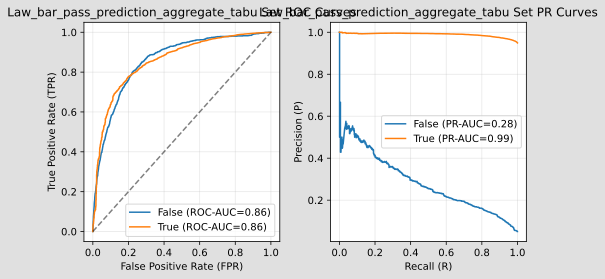

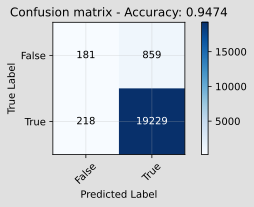

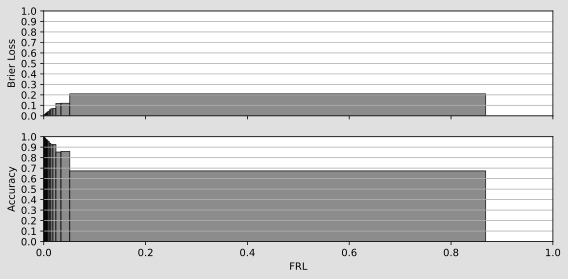

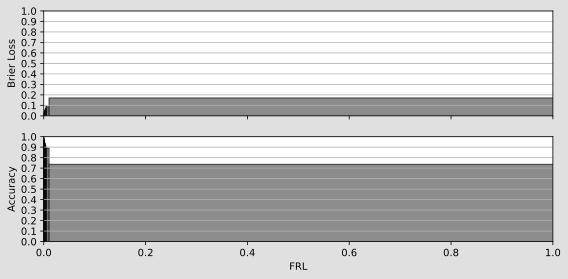

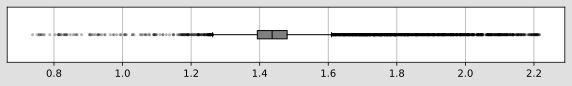

In [20]:
from metrics.fairness import (
    compute_individual_fairness_MRF_cv,
    compute_individual_fairness_cv,
)
from visualization.metrics import plot_stacked_histograms_brier_accuracy
from visualization.utils import linear_n_bins_chooser


top_metrics_to_dataset = {}
for name, dataset in dfs.items():
    if name != "law_bar_pass_prediction":
        continue

    # Extract features
    target, sensible_features, public_features = extract_features(dataset)

    save_path_output_dataset = save_path / name
    save_path_output_dataset.mkdir(parents=True, exist_ok=True)

    dataset_kfold_results = {}
    for fold, (ktrain_df, kval_df) in enumerate(
        stratified_kfold_split(
            dataset,
            target_column=target,
            n_splits=n_splits,
            random_state=random_state,
            shuffle=True,
            keep_original_indexes=True,
        )
    ):
        logger.info(f"Processing fold {fold + 1}/{n_splits} for dataset {name}.")
        logger.debug(
            f"Training set size: {len(ktrain_df)}, Validation set size: {len(kval_df)}"
        )

        if force_arcs:
            # Add arcs from sensible features to target
            learning_params = add_sensible_to_target_arcs(
                learning_params={},
                sensible_features=sensible_features,
                target=target,
            )

            learning_params = add_public_to_target_arcs(
                learning_params=learning_params,
                public_features=public_features,
                target=target,
            )
        else:
            learning_params = {}

        logger.debug(
            f"Learning parameters after adding sensible features: {learning_params}"
        )

        # Learn Bayesian network on the training dataset
        bn = learn_bayesian_network(
            dataset=ktrain_df,
            df_name=name,
            target=target,
            show=False,
            learning_method=learning_method,
            learning_params=learning_params,
        )

        display_and_save_gum_bn(
            bn,
            df_name=name,
            learning_method=learning_method,
            save_path=save_path_output_dataset.as_posix(),
            prefix=f"fold{fold + 1}",
        )

        bn = simplification_1(
            bn,
            name,
            target,
            # name_prefix=f"{name}_{learning_method}_simple1",
        )

        display_and_save_gum_bn(
            bn,
            df_name=name,
            learning_method=learning_method,
            save_path=save_path_output_dataset.as_posix(),
            prefix=f"fold{fold + 1}",
        )

        base_ie = build_inference_engine(bn)
        base_posterior = base_ie.posterior(target).toarray()

        # Evaluate performance
        performance_results, val_df_metrics = evaluate_bn_performance(
            bn=bn,
            ie=base_ie,
            test_df=kval_df,
            target=target,
            save_path=save_path_output_dataset,
            verbose=False,
            drop_duplicates=drop_duplicates,
            matrix_plot_prefix=f"{name}_fold{fold + 1}_{learning_method}",
            curve_plot_prefix=f"{name}_fold{fold + 1}_{learning_method}",
        )

        # Add fold number to the dataframe
        val_df_metrics.loc[:, "Fold"] = fold + 1

        dataset_kfold_results[fold] = {
            "bn": bn,
            "learning_params": learning_params,
            "performance_results": performance_results,
            "val_df_metrics": val_df_metrics,
            "accuracy_per_instance": performance_results["accuracy"],
            "brier_scores_per_instance": performance_results["brier_scores"],
            "brier_scores_abs_per_instance": performance_results["brier_scores_abs"],
        }

    performance_aggregate_results = evaluate_bn_performance_aggregate(
        dataset_kfold_results,
        target,
        save_path_output_dataset,
        matrix_plot_prefix=f"{name}_aggregate_{learning_method}",
        curve_plot_prefix=f"{name}_aggregate_{learning_method}",
    )

    individual_fairness_all_folds_df = compute_individual_fairness_cv(
        kfold_results=dataset_kfold_results,
        name=name,
        target=target,
        learning_method=learning_method,
        performance_results=performance_aggregate_results,
        save_path_output_dataset=save_path_output_dataset,
        drop_duplicates=drop_duplicates,
    )

    simplified_df = individual_fairness_all_folds_df[
        individual_fairness_all_folds_df["Man_Robustness_Individual"]
        == individual_fairness_all_folds_df["Man_Robustness_Max"]
    ].drop_duplicates("ID_row")[
        [
            "Man_Robustness_Individual",
            "Brier_Score",
            "Prediction_Correct",
        ]
    ]

    simplified_df.to_csv(
        save_path_output_dataset / f"{name}_individual_fairness_simplified.csv",
    )

    individual_fairness_MRF_all_folds_df = compute_individual_fairness_MRF_cv(
        kfold_results=dataset_kfold_results,
        individual_fairness_all_folds_df=individual_fairness_all_folds_df,
        name=name,
        target=target,
        save_path_output_dataset=save_path_output_dataset,
    )

    _ = plot_stacked_histograms_brier_accuracy(
        name=name,
        data=individual_fairness_all_folds_df,
        robustness_column_key="Man_Robustness_Max",
        n_bins=linear_n_bins_chooser(
            len(individual_fairness_all_folds_df), 8, 20, samples_per_bin=1000
        ),
        save_path=save_path_output_dataset,
    )

    _ = plot_stacked_histograms_brier_accuracy(
        name=name,
        data=individual_fairness_all_folds_df,
        robustness_column_key="KL_Robustness_Max",
        n_bins=linear_n_bins_chooser(
            len(individual_fairness_all_folds_df), 8, 20, samples_per_bin=1000
        ),
        save_path=save_path_output_dataset,
    )

    plot_brier_vs_robustness(
        fairness_analysis_data=individual_fairness_all_folds_df,
        filename_prefix=f"{name}_individual_fairness_man",
        robustness_column_key="Man_Robustness_Max",
        robustness_bins_strategy="quantile",
        n_bins_brier=5,
        n_bins_robustness=linear_n_bins_chooser(
            len(individual_fairness_all_folds_df), samples_per_bin=1000
        ),
        drop_duplicates=drop_duplicates,
        save_path=save_path_output_dataset,
        metric_name="Brier",
    )

    plot_brier_vs_robustness(
        fairness_analysis_data=individual_fairness_all_folds_df,
        filename_prefix=f"{name}_individual_fairness_man",
        robustness_column_key="Man_Robustness_Max",
        robustness_bins_strategy="quantile",
        n_bins_brier=5,
        n_bins_robustness=linear_n_bins_chooser(
            len(individual_fairness_all_folds_df), samples_per_bin=1000
        ),
        drop_duplicates=drop_duplicates,
        save_path=save_path_output_dataset,
        metric_name="Accuracy",
    )

    timeratios = compute_time_ratios(
        individual_fairness_bn=individual_fairness_all_folds_df,
        individual_fairness_mrf=individual_fairness_MRF_all_folds_df,
        save_path=save_path_output_dataset,
    )

    plot_boxplot_timeratios(
        name=name,
        learning_method=learning_method,
        timeratios=timeratios,
        save_path=save_path_output_dataset,
    )
    break